# Bulk Historical FIRMS Download Validation

Goal for this notebook is to validate the FIRMS archive CSV files as the source for multi-year training data (just CA for now), and compare their schema against the area API responses used in the eda_firms_wfigs_current.ipynb notebook.

looking at FIRMS sources:

- VIIRS S-NPP - 375m resolution and prior EDA shows it meets the needs
- VIIRS NOAA-20 - Same 375m resolution and adds passes (~4/day vs ~2), improves temporal coverage for clustering 
- MODIS - 1km pixels -> lower resolution, noisier clusters -> seems redundant given VIIRS 
- VIIRS NOAA-21 - Launched 2024 so not a lot of data to use for training
- Landsat - Post-fire burn severity not active fire detections, and has 16-day revisit

--> decision: use VIIRS S-NPP and NOAA-20


first need to download VIIRS S-NPP and VIIRS NOAA-20 yearly archive CSV files from `https://firms.modaps.eosdis.nasa.gov/download/`. Downloading CA with 5km buffer for 2018-2023.


In [ ]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from io import StringIO

os.makedirs("data/firms_historical", exist_ok=True)
os.makedirs("plots", exist_ok=True)

In [ ]:
# CA bounding box (min_lon, min_lat, max_lon, max_lat)
CA_BBOX = (
    -124.41060660766607,
    32.5342307609976,
    -114.13445790587905,
    42.00965914828148,
)

ARCHIVE_DIR = Path("data/firms_archive")

AREA_API_COLUMNS = [
    "latitude",
    "longitude",
    "bright_ti4",
    "scan",
    "track",
    "acq_date",
    "acq_time",
    "satellite",
    "instrument",
    "confidence",
    "version",
    "bright_ti5",
    "frp",
    "daynight",
    "type",
]

In [ ]:
archive_files = sorted(ARCHIVE_DIR.glob("*.zip")) + sorted(ARCHIVE_DIR.glob("*.csv"))

print(f"Found {len(archive_files)} archive file(s):")
for f in archive_files:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}  ({size_mb:.1f} MB)")

Found 2 archive file(s):
  fire_archive_J1V-C2_749170.csv  (51.3 MB)
  fire_archive_SV-C2_749171.csv  (50.1 MB)


In [69]:
def load_archive_file(path):
    """Load a FIRMS archive file (.zip or .csv) into a DataFrame.

    Zips may contain multiple CSVs (e.g. one per satellite or month);
    all are concatenated rather than dropping all but the first.
    """
    if path.suffix == ".zip":
        with zipfile.ZipFile(path) as zf:
            csv_names = [n for n in zf.namelist() if n.endswith(".csv")]
            if not csv_names:
                raise ValueError(f"No CSV found inside {path.name}")
            if len(csv_names) > 1:
                print(
                    f"  {path.name}: concatenating {len(csv_names)} CSVs — {csv_names}"
                )
            frames = [pd.read_csv(zf.open(name)) for name in csv_names]
            return pd.concat(frames, ignore_index=True)
    else:
        return pd.read_csv(path)


def filter_to_ca(df):
    min_lon, min_lat, max_lon, max_lat = CA_BBOX
    return df[
        (df["longitude"] >= min_lon)
        & (df["longitude"] <= max_lon)
        & (df["latitude"] >= min_lat)
        & (df["latitude"] <= max_lat)
    ].copy()

In [ ]:
satellite_raw = {}
for f in archive_files:
    tag = "J1/NOAA-20" if "J1V" in f.name else "SV/SNPP"
    df = load_archive_file(f)
    satellite_raw[tag] = df
    print(f"{tag} ({f.name}): {len(df):,} rows, columns: {list(df.columns)}")

col_lists = [list(df.columns) for df in satellite_raw.values()]
print(f"\nSchemas match: {all(c == col_lists[0] for c in col_lists[1:])}")

raw_df_NOA = satellite_raw["J1/NOAA-20"]
raw_df_SNPP = satellite_raw["SV/SNPP"]
raw_df = raw_df_NOA

print("\nNOAA-20 sample rows:")
display(raw_df_NOA.head(3))
print("\nSNPP sample rows:")
display(raw_df_SNPP.head(3))

J1/NOAA-20 (fire_archive_J1V-C2_749170.csv): 623,516 rows, columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
SV/SNPP (fire_archive_SV-C2_749171.csv): 623,585 rows, columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']

Schemas match: True

NOAA-20 sample rows:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,41.48973,-122.52775,299.63,0.39,0.36,2018-04-01,1001,N20,VIIRS,n,2,277.25,0.78,N,0
1,39.94645,-122.23311,304.87,0.38,0.36,2018-04-01,1001,N20,VIIRS,n,2,279.65,1.02,N,0
2,39.94577,-122.22865,313.67,0.38,0.36,2018-04-01,1001,N20,VIIRS,n,2,280.46,1.03,N,0



SNPP sample rows:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,36.62250,-119.95790,319.26,0.45,0.63,2018-01-01,859,N,VIIRS,n,2,276.46,1.93,N,0
1,36.07023,-119.26259,296.57,0.41,0.60,2018-01-01,900,N,VIIRS,n,2,274.67,0.70,N,0
2,34.60802,-117.33579,298.52,0.61,0.54,2018-01-01,900,N,VIIRS,n,2,274.78,1.22,N,2


## compare columns in archive and area API

In [71]:
archive_cols = set(raw_df.columns)
api_cols = set(AREA_API_COLUMNS)

print("In archive but NOT in area API:", archive_cols - api_cols or "none")
print("In area API but NOT in archive:", api_cols - archive_cols or "none")

print("\nArchive dtypes (same for both satellites):")
print(raw_df.dtypes)

In archive but NOT in area API: {'brightness', 'bright_t31'}
In area API but NOT in archive: {'bright_ti4', 'bright_ti5'}

Archive dtypes (same for both satellites):
latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date          str
acq_time        int64
satellite         str
instrument        str
confidence        str
version         int64
bright_t31    float64
frp           float64
daynight          str
type            int64
dtype: object


In [ ]:
print("\nNOAA-20:")
print("acq_date sample:", raw_df_NOA["acq_date"].head(5).tolist())
print("acq_time sample:", raw_df_NOA["acq_time"].head(10).tolist())
print("version unique values:", raw_df_NOA["version"].unique())
print("satellite unique values:", raw_df_NOA["satellite"].unique())
print("confidence unique values:", raw_df_NOA["confidence"].unique())

print("\nSNPP:")
print("acq_date sample:", raw_df_SNPP["acq_date"].head(5).tolist())
print("acq_time sample:", raw_df_SNPP["acq_time"].head(10).tolist())
print("version unique values:", raw_df_SNPP["version"].unique())
print("satellite unique values:", raw_df_SNPP["satellite"].unique())
print("confidence unique values:", raw_df_SNPP["confidence"].unique())


NOAA-20:
acq_date sample: ['2018-04-01', '2018-04-01', '2018-04-01', '2018-04-01', '2018-04-01']
acq_time sample: [1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001]
version unique values: [2]
satellite unique values: <StringArray>
['N20']
Length: 1, dtype: str
confidence unique values: <StringArray>
['n', 'l', 'h']
Length: 3, dtype: str

SNPP:
acq_date sample: ['2018-01-01', '2018-01-01', '2018-01-01', '2018-01-01', '2018-01-01']
acq_time sample: [859, 900, 900, 900, 900, 900, 900, 900, 900, 900]
version unique values: [2]
satellite unique values: <StringArray>
['N']
Length: 1, dtype: str
confidence unique values: <StringArray>
['n', 'h', 'l']
Length: 3, dtype: str


## filtering to CA and comparing distributions across satellites

In [ ]:
satellite_ca = {}
for tag, raw in satellite_raw.items():
    ca = filter_to_ca(raw)
    ca["acq_date"] = pd.to_datetime(ca["acq_date"])
    satellite_ca[tag] = ca
    print(
        f"{tag}: {len(raw):,} total -> {len(ca):,} CA ({len(ca)/len(raw):.1%})"
        f"  |  {ca['acq_date'].min().date()} - {ca['acq_date'].max().date()}"
    )

# Keep ca_test pointing to NOAA-20 for the field-format cells that still reference it
ca_test = satellite_ca["J1/NOAA-20"]

J1/NOAA-20: 623,516 total → 621,161 CA (99.6%)  |  2018-04-01 – 2023-12-31
SV/SNPP: 623,585 total → 621,269 CA (99.6%)  |  2018-01-01 – 2023-12-31


In [74]:
for tag, df in satellite_ca.items():
    print(f"\n=== {tag} ===")
    print("Type distribution:")
    print(df["type"].value_counts(normalize=True).round(3).to_string())
    print("\nConfidence distribution:")
    print(df["confidence"].value_counts(normalize=True).round(3).to_string())
    print("\nMean FRP by confidence:")
    print(df.groupby("confidence")["frp"].mean().round(1).to_string())


=== J1/NOAA-20 ===
Type distribution:
type
0    0.938
2    0.061
3    0.001

Confidence distribution:
confidence
n    0.893
h    0.066
l    0.042

Mean FRP by confidence:
confidence
h    59.0
l    81.3
n    10.9

=== SV/SNPP ===
Type distribution:
type
0    0.940
2    0.058
3    0.001

Confidence distribution:
confidence
n    0.884
h    0.074
l    0.043

Mean FRP by confidence:
confidence
h    57.1
l    81.7
n    10.9


## archive --> parquet

In [ ]:
summary_rows = []

for f in archive_files:
    out_path = Path("data/firms_historical") / (f.stem + "_ca.parquet")

    if out_path.exists():
        ca = pd.read_parquet(out_path, engine="fastparquet")
        ca["acq_date"] = pd.to_datetime(ca["acq_date"])
        print(f"{f.name}: cached — {len(ca):,} CA rows")
    else:
        raw = load_archive_file(f)
        ca = filter_to_ca(raw)
        ca["acq_date"] = pd.to_datetime(ca["acq_date"])
        ca.to_parquet(out_path, index=False, engine="fastparquet")
        size_mb = out_path.stat().st_size / 1e6
        print(
            f"{f.name}: {len(raw):,} total -> {len(ca):,} CA -> {out_path.name} ({size_mb:.1f} MB)"
        )

    summary_rows.append(
        {
            "source_file": f.name,
            "ca_hotspots": len(ca),
            "date_min": ca["acq_date"].min().date(),
            "date_max": ca["acq_date"].max().date(),
            "years_covered": sorted(ca["acq_date"].dt.year.unique().tolist()),
            "type0_frac": round((ca["type"] == 0).mean(), 3),
            "frp_mean": round(ca["frp"].mean(), 1),
            "frp_max": round(ca["frp"].max(), 0),
            "parquet_path": str(out_path),
        }
    )

summary = pd.DataFrame(summary_rows)
summary

fire_archive_J1V-C2_749170.csv: cached — 621,161 CA rows
fire_archive_SV-C2_749171.csv: cached — 621,269 CA rows


,source_file,ca_hotspots,date_min,date_max,years_covered,type0_frac,frp_mean,frp_max,parquet_path
0,fire_archive_J1V-C2_749170.csv,621161,2018-04-01,2023-12-31,"[2018, 2019, 2020, 2021, 2022, 2023]",0.938,17.0,3348.0,data/firms_historical/fire_archive_J1V-C2_7491...
1,fire_archive_SV-C2_749171.csv,621269,2018-01-01,2023-12-31,"[2018, 2019, 2020, 2021, 2022, 2023]",0.940,17.3,2817.0,data/firms_historical/fire_archive_SV-C2_74917...


## single fire spot check

From `eda_historical_ics209.ipynb`: 24,332 raw hotspots in the DOE fire bbox (Aug 17-Sep 4, 2020) via the area API using VIIRS S-NPP SP. Compare both archive parquets against that reference to make sure they are same or very close:
- S-NPP archive count should be close to 24,332 (same satellite, same product version)
- NOAA-20 archive count will differ, it is a separate satellite with independent passes

In [76]:
parquet_files = sorted(Path("data/firms_historical").glob("*_ca.parquet"))

doe_parquets = {}
for p in parquet_files:
    tag = "J1/NOAA-20" if "J1V" in p.name else "SV/SNPP"
    doe_parquets[tag] = p
    print(f"{tag}: {p.name}")

if not doe_parquets:
    print("No CA parquet files found — run cell 5 first")

J1/NOAA-20: fire_archive_J1V-C2_749170_ca.parquet
SV/SNPP: fire_archive_SV-C2_749171_ca.parquet


In [77]:
DOE_BBOX = (-122.5, 38.0, -120.5, 40.5)
DOE_START, DOE_END = "2020-08-17", "2020-09-04"

doe_counts = {}
for tag, p in doe_parquets.items():
    df = pd.read_parquet(p, engine="fastparquet")
    df["acq_date"] = pd.to_datetime(df["acq_date"])
    doe = df[
        (df["acq_date"] >= DOE_START)
        & (df["acq_date"] <= DOE_END)
        & (df["longitude"] >= DOE_BBOX[0])
        & (df["longitude"] <= DOE_BBOX[2])
        & (df["latitude"] >= DOE_BBOX[1])
        & (df["latitude"] <= DOE_BBOX[3])
    ]
    doe_counts[tag] = doe
    print(f"{tag}: {len(doe):,} hotspots in DOE bbox")

snpp_count = len(doe_counts.get("SV/SNPP", pd.DataFrame()))
print(f"\nArea API reference (S-NPP SP, eda_historical_ics209.ipynb): 24,332 hotspots")
if snpp_count:
    print(f"S-NPP archive / API ratio: {snpp_count / 24332:.3f}")

print("\nDaily hotspot counts by satellite:")
daily = {tag: doe.groupby("acq_date").size() for tag, doe in doe_counts.items()}
print(pd.DataFrame(daily).fillna(0).astype(int).to_string())

J1/NOAA-20: 13,258 hotspots in DOE bbox
SV/SNPP: 11,969 hotspots in DOE bbox

Area API reference (S-NPP SP, eda_historical_ics209.ipynb): 24,332 hotspots
S-NPP archive / API ratio: 0.492

Daily hotspot counts by satellite:
            J1/NOAA-20  SV/SNPP
acq_date                       
2020-08-17          23       27
2020-08-18         398      626
2020-08-19        4019     3409
2020-08-20        3311     2325
2020-08-21        1517     1059
2020-08-22         774      737
2020-08-23         718     1136
2020-08-24         191      250
2020-08-25         283      288
2020-08-26         360      395
2020-08-27         271      316
2020-08-28         284      264
2020-08-29         214      232
2020-08-30         140      143
2020-08-31         102      157
2020-09-01         139      147
2020-09-02         216      180
2020-09-03         148      128
2020-09-04         150      150


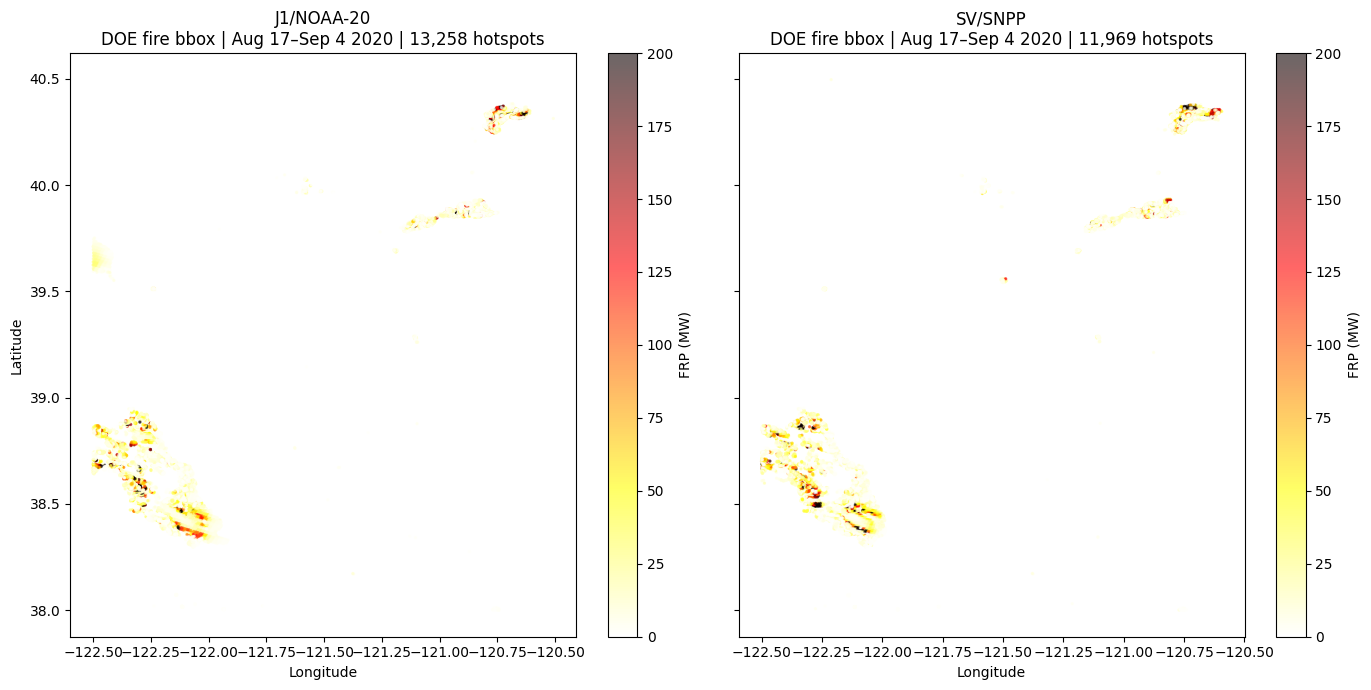

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for ax, (tag, doe) in zip(axes, doe_counts.items()):
    sc = ax.scatter(
        doe["longitude"],
        doe["latitude"],
        c=doe["frp"],
        cmap="hot_r",
        s=2,
        vmin=0,
        vmax=200,
        alpha=0.6,
    )
    plt.colorbar(sc, ax=ax, label="FRP (MW)")
    ax.set_title(f"{tag}\nDOE fire bbox | Aug 17-Sep 4 2020 | {len(doe):,} hotspots")
    ax.set_xlabel("Longitude")

axes[0].set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("plots/bulk_doe_spotcheck.png", dpi=150, bbox_inches="tight")
plt.show()

differing hotspot counts in the archive and area API from before (12k vs 24k) ... further investigation needed -_- ... which is a few sections down

## monthly hotspot heatmap across 2018-2023

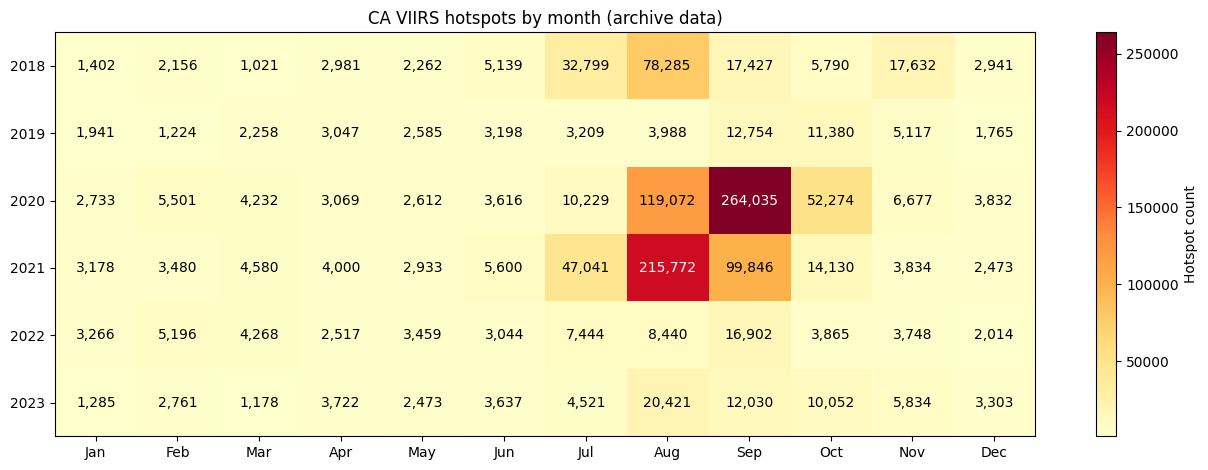


Fire season fraction (May–Oct hotspots / annual total):
year
2018    0.83
2019    0.71
2020    0.95
2021    0.95
2022    0.67
2023    0.75


In [ ]:
parquet_files = sorted(Path("data/firms_historical").glob("*_ca.parquet"))

if not parquet_files:
    print("No CA parquet files found — run cell 5 first")
else:
    all_dates = pd.concat(
        [
            pd.read_parquet(p, columns=["acq_date"], engine="fastparquet")
            for p in parquet_files
        ]
    )
    all_dates["acq_date"] = pd.to_datetime(all_dates["acq_date"])
    all_dates["year"] = all_dates["acq_date"].dt.year
    all_dates["month"] = all_dates["acq_date"].dt.month

    monthly = all_dates.groupby(["year", "month"]).size().unstack(fill_value=0)
    month_labels = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    fig, ax = plt.subplots(figsize=(13, max(3, len(monthly) * 0.8)))
    im = ax.imshow(monthly.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(monthly.columns)))
    ax.set_xticklabels([month_labels[m - 1] for m in monthly.columns])
    ax.set_yticks(range(len(monthly)))
    ax.set_yticklabels(monthly.index.tolist())
    plt.colorbar(im, ax=ax, label="Hotspot count")
    ax.set_title("CA VIIRS hotspots by month (archive data)")

    for i in range(len(monthly.index)):
        for j in range(len(monthly.columns)):
            val = monthly.iloc[i, j]
            if val > 0:
                ax.text(
                    j,
                    i,
                    f"{val:,}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white" if val > monthly.values.max() * 0.5 else "black",
                )

    plt.tight_layout()
    plt.savefig("plots/bulk_monthly_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nFire season fraction (May-Oct hotspots / annual total):")
    season_cols = [c for c in monthly.columns if 5 <= c <= 10]
    print((monthly[season_cols].sum(axis=1) / monthly.sum(axis=1)).round(2).to_string())

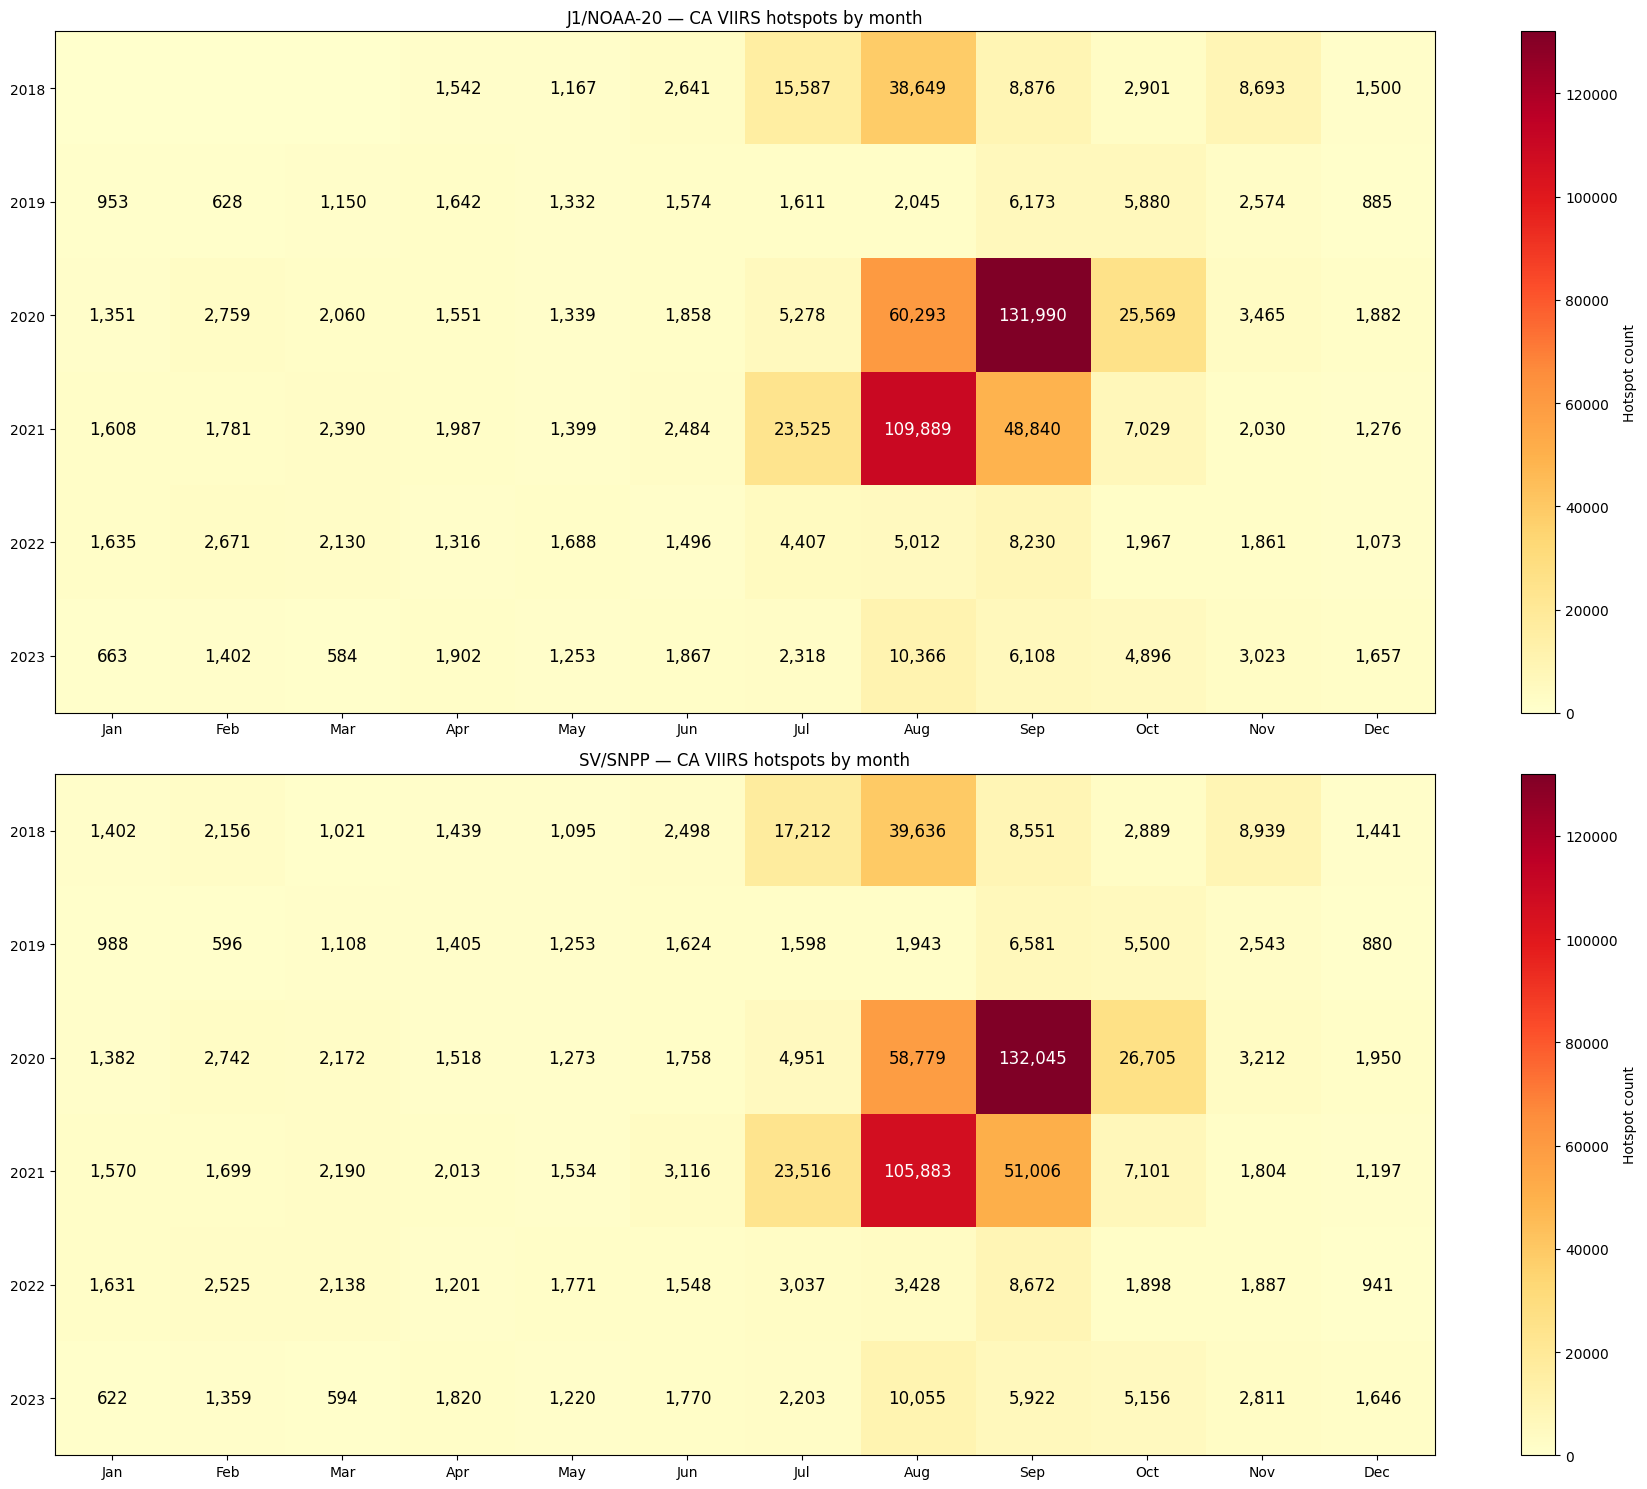


Fire season fraction (May–Oct) per satellite:

J1/NOAA-20:
acq_date
2018    0.86
2019    0.70
2020    0.95
2021    0.95
2022    0.68
2023    0.74

SV/SNPP:
acq_date
2018    0.81
2019    0.71
2020    0.95
2021    0.95
2022    0.66
2023    0.75


In [80]:
# Per-satellite monthly heatmaps side by side
parquet_files = sorted(Path("data/firms_historical").glob("*_ca.parquet"))

sat_monthlies = {}
for p in parquet_files:
    tag = "J1/NOAA-20" if "J1V" in p.name else "SV/SNPP"
    dates = pd.read_parquet(p, columns=["acq_date"], engine="fastparquet")["acq_date"]
    dates = pd.to_datetime(dates)
    monthly = (
        dates.groupby([dates.dt.year, dates.dt.month]).count().unstack(fill_value=0)
    )
    sat_monthlies[tag] = monthly

month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
vmax = max(m.values.max() for m in sat_monthlies.values())

fig, axes = plt.subplots(2, 1, figsize=(18, 15))

for ax, (tag, monthly) in zip(axes, sat_monthlies.items()):
    im = ax.imshow(monthly.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(monthly.columns)))
    ax.set_xticklabels([month_labels[m - 1] for m in monthly.columns])
    ax.set_yticks(range(len(monthly)))
    ax.set_yticklabels(monthly.index.tolist())
    plt.colorbar(im, ax=ax, label="Hotspot count")
    ax.set_title(f"{tag} — CA VIIRS hotspots by month")
    for i in range(len(monthly.index)):
        for j in range(len(monthly.columns)):
            val = monthly.iloc[i, j]
            if val > 0:
                ax.text(
                    j,
                    i,
                    f"{val:,}",
                    ha="center",
                    va="center",
                    fontsize=12,
                    color="white" if val > vmax * 0.5 else "black",
                )

plt.tight_layout()
plt.savefig(
    "plots/bulk_monthly_heatmap_per_satellite.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nFire season fraction (May–Oct) per satellite:")
for tag, monthly in sat_monthlies.items():
    season_cols = [c for c in monthly.columns if 5 <= c <= 10]
    frac = (monthly[season_cols].sum(axis=1) / monthly.sum(axis=1)).round(2)
    print(f"\n{tag}:")
    print(frac.to_string())

## schema summary

In [81]:
parquet_files = sorted(Path("data/firms_historical").glob("*_ca.parquet"))

if not parquet_files:
    print("No CA parquet files found — run cell 5 first")
else:
    sample = pd.read_parquet(parquet_files[0], engine="fastparquet")

    schema = pd.DataFrame(
        {
            "dtype": sample.dtypes,
            "in_area_api": [col in AREA_API_COLUMNS for col in sample.columns],
            "null_frac": sample.isnull().mean().round(4),
            "sample_value": [
                str(sample[col].dropna().iloc[0]) if sample[col].notna().any() else ""
                for col in sample.columns
            ],
        }
    )

    print("Archive schema vs area API:")
    print(schema.to_string())

    extra = set(sample.columns) - set(AREA_API_COLUMNS)
    missing = set(AREA_API_COLUMNS) - set(sample.columns)
    print(f"\nExtra columns (archive only): {extra or 'none'}")
    print(f"Missing columns (API only):   {missing or 'none'}")

Archive schema vs area API:
                     dtype  in_area_api  null_frac         sample_value
latitude           float64         True        0.0             41.48973
longitude          float64         True        0.0           -122.52775
brightness         float64        False        0.0               299.63
scan               float64         True        0.0                 0.39
track              float64         True        0.0                 0.36
acq_date    datetime64[us]         True        0.0  2018-04-01 00:00:00
acq_time             int64         True        0.0                 1001
satellite           object         True        0.0                  N20
instrument          object         True        0.0                VIIRS
confidence          object         True        0.0                    n
version              int64         True        0.0                    2
bright_t31         float64        False        0.0               277.25
frp                float64         T

## discrepancy investigation for S-NPP archive vs area API

Earlier, we saw S-NPP archive yields ~12k hotspots in the DOE bbox vs 24,332 from the area API in `eda_historical_ics209.ipynb`, which is roughly half.

Possible reason for this: the two bounding boxes are different. The historical notebook used a bbox centered on the ICS-209 origin +/- 1 degree, while the DOE_BBOX hardcoded above is a different rectangle. Before looking at data-quality or product-version explanations, should verify whether the same bbox + date range produces the same count from the archive.

Bounding box comparison
                         min_lon   min_lat     max_lon   max_lat
Bulk DOE_BBOX          -122.5000   38.0000   -120.5000   40.5000
API bbox               -123.6733   38.7654   -121.6733   40.7654

Bboxes overlap: True
  Overlap lon: -122.5000 – -121.6733  (0.8267°)
  Overlap lat: 38.7654 – 40.5000  (1.7346°)


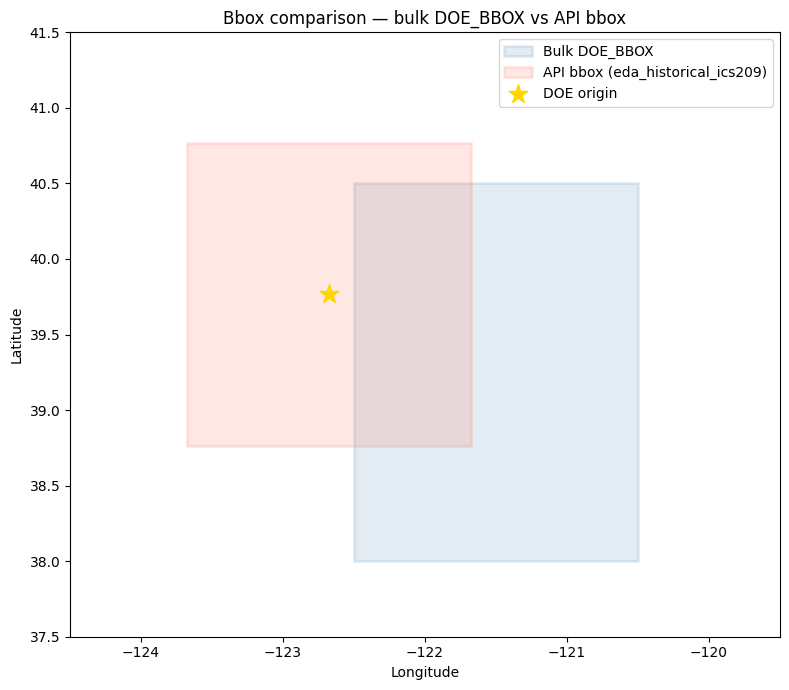

In [ ]:
import matplotlib.patches as mpatches

# Bulk notebook DOE_BBOX (hardcoded above)
BULK_BBOX = (-122.5, 38.0, -120.5, 40.5)

# API bbox from eda_historical_ics209.ipynb
API_LON0, API_LAT0, API_PAD = -122.6733, 39.7654, 1.0
API_BBOX = (
    API_LON0 - API_PAD,
    API_LAT0 - API_PAD,
    API_LON0 + API_PAD,
    API_LAT0 + API_PAD,
)

print("Bounding box comparison")
print(f"{'':20s}  {'min_lon':>10}  {'min_lat':>8}  {'max_lon':>10}  {'max_lat':>8}")
print(
    f"{'Bulk DOE_BBOX':20s}  {BULK_BBOX[0]:>10.4f}  {BULK_BBOX[1]:>8.4f}  {BULK_BBOX[2]:>10.4f}  {BULK_BBOX[3]:>8.4f}"
)
print(
    f"{'API bbox':20s}  {API_BBOX[0]:>10.4f}  {API_BBOX[1]:>8.4f}  {API_BBOX[2]:>10.4f}  {API_BBOX[3]:>8.4f}"
)

overlap_lon = (max(BULK_BBOX[0], API_BBOX[0]), min(BULK_BBOX[2], API_BBOX[2]))
overlap_lat = (max(BULK_BBOX[1], API_BBOX[1]), min(BULK_BBOX[3], API_BBOX[3]))
overlaps = overlap_lon[0] < overlap_lon[1] and overlap_lat[0] < overlap_lat[1]
print(f"\nBboxes overlap: {overlaps}")
if overlaps:
    print(
        f"  Overlap lon: {overlap_lon[0]:.4f} – {overlap_lon[1]:.4f}  ({overlap_lon[1]-overlap_lon[0]:.4f}°)"
    )
    print(
        f"  Overlap lat: {overlap_lat[0]:.4f} - {overlap_lat[1]:.4f}  ({overlap_lat[1]-overlap_lat[0]:.4f}°)"
    )

fig, ax = plt.subplots(figsize=(8, 7))


def draw_bbox(ax, bbox, color, label, alpha=0.15):
    min_lon, min_lat, max_lon, max_lat = bbox
    rect = mpatches.FancyArrowPatch((min_lon, min_lat), (max_lon, max_lat), color=color)
    ax.add_patch(
        mpatches.Rectangle(
            (min_lon, min_lat),
            max_lon - min_lon,
            max_lat - min_lat,
            linewidth=2,
            edgecolor=color,
            facecolor=color,
            alpha=alpha,
            label=label,
        )
    )


draw_bbox(ax, BULK_BBOX, "steelblue", "Bulk DOE_BBOX")
draw_bbox(ax, API_BBOX, "tomato", "API bbox (eda_historical_ics209)")
ax.scatter(
    [API_LON0],
    [API_LAT0],
    marker="*",
    s=200,
    color="gold",
    zorder=5,
    label="DOE origin",
)
ax.set_xlim(-124.5, -119.5)
ax.set_ylim(37.5, 41.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bbox comparison - bulk DOE_BBOX vs API bbox")
ax.legend()
plt.tight_layout()
plt.savefig("plots/discrepancy_bbox_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# re-filter the S-NPP parquet using the exact API bbox and date range
snpp_path = next(
    p
    for p in sorted(Path("data/firms_historical").glob("*_ca.parquet"))
    if "SV" in p.name
)
snpp = pd.read_parquet(snpp_path, engine="fastparquet")
snpp["acq_date"] = pd.to_datetime(snpp["acq_date"])

API_START, API_END = "2020-08-16", "2020-09-04"


def filter_bbox_dates(df, bbox, start, end):
    min_lon, min_lat, max_lon, max_lat = bbox
    return df[
        (df["acq_date"] >= start)
        & (df["acq_date"] <= end)
        & (df["longitude"] >= min_lon)
        & (df["longitude"] <= max_lon)
        & (df["latitude"] >= min_lat)
        & (df["latitude"] <= max_lat)
    ]


snpp_bulk = filter_bbox_dates(snpp, BULK_BBOX, "2020-08-17", "2020-09-04")
snpp_api = filter_bbox_dates(snpp, API_BBOX, API_START, API_END)

print(f"S-NPP archive  |  Bulk bbox  (Aug 17–Sep 4): {len(snpp_bulk):>6,}")
print(f"S-NPP archive  |  API bbox   (Aug 16-Sep 4): {len(snpp_api):>6,}")
print(f"Area API result (eda_historical_ics209.ipynb): {24332:>6,}")
print(f"\nAPI bbox archive / API result ratio: {len(snpp_api) / 24332:.3f}")

# from eda_historical_ics209.ipynb DOE spot check output
api_daily_ref = {
    "2020-08-17": 23,
    "2020-08-18": 626,
    "2020-08-19": 3409,
    "2020-08-20": 2325,
    "2020-08-21": 1059,
    "2020-08-22": 737,
    "2020-08-23": 1136,
    "2020-08-24": 250,
    "2020-08-25": 288,
    "2020-08-26": 395,
    "2020-08-27": 316,
    "2020-08-28": 264,
    "2020-08-29": 232,
    "2020-08-30": 143,
    "2020-08-31": 157,
    "2020-09-01": 147,
    "2020-09-02": 180,
    "2020-09-03": 128,
    "2020-09-04": 150,
}
archive_daily = snpp_api.groupby(snpp_api["acq_date"].dt.date.astype(str)).size()

compare = (
    pd.DataFrame(
        {
            "archive (API bbox)": archive_daily,
            "area API (ref)": pd.Series(api_daily_ref),
        }
    )
    .fillna(0)
    .astype(int)
)
compare["diff"] = compare["archive (API bbox)"] - compare["area API (ref)"]
print("\nDaily count comparison (archive vs area API reference):")
print(compare.to_string())

S-NPP archive  |  Bulk bbox  (Aug 17–Sep 4): 11,969
S-NPP archive  |  API bbox   (Aug 16–Sep 4): 24,332
Area API result (eda_historical_ics209.ipynb): 24,332

API bbox archive / API result ratio: 1.000

Daily count comparison (archive vs area API reference):
            archive (API bbox)  area API (ref)  diff
2020-08-17                  85              23    62
2020-08-18                 127             626  -499
2020-08-19                2481            3409  -928
2020-08-20                2807            2325   482
2020-08-21                1903            1059   844
2020-08-22                1357             737   620
2020-08-23                1403            1136   267
2020-08-24                 351             250   101
2020-08-25                 983             288   695
2020-08-26                 884             395   489
2020-08-27                 988             316   672
2020-08-28                1306             264  1042
2020-08-29                 859             232   627

still seeing a diff, now do a row-level equality check. Pull two days from the area API and match against the archive data on lat/lon and acq_date/acq_time. Will use Aug 19 (,409 API detections) and Aug 22 (737 API detections)

In [ ]:
MAP_KEY = "<get_your_own_key_buddy>"
PRODUCT = "VIIRS_SNPP_SP"
CHECK_DATES = [("2020-08-19", 1), ("2020-08-22", 1)]
API_BBOX_STR = (
    f"{API_BBOX[0]:.4f},{API_BBOX[1]:.4f},{API_BBOX[2]:.4f},{API_BBOX[3]:.4f}"
)

api_frames = []
for start_date, days in CHECK_DATES:
    url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{PRODUCT}/{API_BBOX_STR}/{days}/{start_date}"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.content.decode("utf-8")))
    df["acq_date"] = pd.to_datetime(df["acq_date"])
    api_frames.append(df)
    print(f"API {start_date}: {len(df):,} rows")

api_spot = pd.concat(api_frames, ignore_index=True)

# Archive rows for the same dates and bbox
archive_spot = filter_bbox_dates(snpp, API_BBOX, "2020-08-19", "2020-08-22")
archive_spot = archive_spot[archive_spot["acq_date"].isin(api_spot["acq_date"])]

print(f"\nAPI rows (2 days):     {len(api_spot):,}")
print(f"Archive rows (2 days): {len(archive_spot):,}")


# Match key: round lat/lon to 4 places (~11m which is sub-pixel), exact acq_date + acq_time
def make_key(df):
    return (
        df["latitude"].round(4).astype(str)
        + "_"
        + df["longitude"].round(4).astype(str)
        + "_"
        + df["acq_date"].astype(str)
        + "_"
        + df["acq_time"].astype(str)
    )


api_keys = set(make_key(api_spot))
archive_keys = set(make_key(archive_spot))

matched = api_keys & archive_keys
api_only = api_keys - archive_keys
arch_only = archive_keys - api_keys

print(f"\nRow-level match (lat/lon/date/time):")
print(
    f"  Matched (in both):    {len(matched):,}  ({len(matched)/len(api_keys):.1%} of API rows)"
)
print(f"  API-only (not in archive): {len(api_only):,}")
print(f"  Archive-only (not in API): {len(arch_only):,}")

# check: are there column-level differences for matched rows?
if matched:
    sample_key = next(iter(matched))
    lat_s, lon_s, date_s, time_s = sample_key.split("_")
    api_row = api_spot[
        (api_spot["latitude"].round(4).astype(str) == lat_s)
        & (api_spot["acq_time"].astype(str) == time_s)
    ].iloc[0]
    archive_row = archive_spot[
        (archive_spot["latitude"].round(4).astype(str) == lat_s)
        & (archive_spot["acq_time"].astype(str) == time_s)
    ].iloc[0]
    print(f"\nSample matched row — field comparison:")
    print(f"  {'Field':15s}  {'API value':>15}  {'Archive value':>15}")
    for field, api_field, arch_field in [
        ("latitude", "latitude", "latitude"),
        ("longitude", "longitude", "longitude"),
        ("acq_time", "acq_time", "acq_time"),
        ("frp", "frp", "frp"),
        ("brightness", "bright_ti4", "brightness"),
        ("bright_t31", "bright_ti5", "bright_t31"),
        ("confidence", "confidence", "confidence"),
        ("version", "version", "version"),
    ]:
        api_val = api_row.get(api_field, "N/A")
        arch_val = archive_row.get(arch_field, "N/A")
        match_flag = "✓" if str(api_val) == str(arch_val) else "≠"
        print(f"  {match_flag} {field:15s}  {str(api_val):>15}  {str(arch_val):>15}")

API 2020-08-19: 2,481 rows
API 2020-08-22: 1,357 rows

API rows (2 days):     3,838
Archive rows (2 days): 3,838

Row-level match (lat/lon/date/time):
  Matched (in both):    3,838  (100.0% of API rows)
  API-only (not in archive): 0
  Archive-only (not in API): 0

Sample matched row — field comparison:
  Field                  API value    Archive value
  ✓ latitude                39.69621         39.69621
  ✓ longitude             -122.76588       -122.76588
  ✓ acq_time                    1020             1020
  ✓ frp                        14.38            14.38
  ✓ brightness                323.05           323.05
  ✓ bright_t31                294.91           294.91
  ✓ confidence                     n                n
  ✓ version                        2                2


so that was the issue, phew. Note to self: ensure bounding boxes are the same and joining on same metadata